### Model 2 notebook code

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# Main repository directory
BASE_DIR = Path.cwd().parent

# Repository folders
OUTPUT_DIR = BASE_DIR / "outputs"
MODEL_DIR = BASE_DIR / "models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Repository:", BASE_DIR)
print("Outputs folder exists:", OUTPUT_DIR.exists())
print("Models folder exists:", MODEL_DIR.exists())

Repository: C:\Users\Lenovo\OneDrive\Documents\StadioCare-performance-analysis
Outputs folder exists: True
Models folder exists: True


### Load the processed datasets

In [4]:

X_train = joblib.load(
    OUTPUT_DIR / "X_train_processed.joblib"
)

X_test = joblib.load(
    OUTPUT_DIR / "X_test_processed.joblib"
)

# Load processed target variables
y_train = joblib.load(
    OUTPUT_DIR / "y_train_processed.joblib"
)

y_test = joblib.load(
    OUTPUT_DIR / "y_test_processed.joblib"
)


y_train = np.asarray(y_train).ravel()
y_test = np.asarray(y_test).ravel()

# Display dataset information
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

print("Training positive cases:", np.sum(y_train == 1))
print("Testing positive cases:", np.sum(y_test == 1))

Training features: (81613, 2419)
Testing features: (20153, 2419)
Training target: (81613,)
Testing target: (20153,)
Training positive cases: 9206
Testing positive cases: 2151


### Build and train the Random Forest model

In [6]:

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


### predictions

In [8]:

y_pred_rf = random_forest_model.predict(X_test)

# Predict probability of readmission within 30 days
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

print("First 10 predicted classes:")
print(y_pred_rf[:10])

print("\nFirst 10 predicted probabilities:")
print(y_prob_rf[:10])

Predictions generated successfully.
First 10 predicted classes:
[1 0 0 0 0 0 0 1 0 0]

First 10 predicted probabilities:
[0.53251612 0.42681604 0.48576661 0.49599884 0.48699229 0.43488241
 0.43000281 0.60475474 0.46986614 0.43383373]


### performance metrics

In [9]:
# Calculate metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(
    y_test, y_pred_rf, zero_division=0
)

recall_rf = recall_score(
    y_test, y_pred_rf, zero_division=0
)

f1_rf = f1_score(
    y_test, y_pred_rf, zero_division=0
)

roc_auc_rf = roc_auc_score(
    y_test, y_prob_rf
)

pr_auc_rf = average_precision_score(
    y_test, y_prob_rf
)

# Create results table
results_rf = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Score": [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf,
        roc_auc_rf,
        pr_auc_rf
    ]
})

print(results_rf.to_string(index=False))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "Not readmitted within 30 days",
            "Readmitted within 30 days"
        ],
        zero_division=0
    )
)

   Metric    Score
 Accuracy 0.644420
Precision 0.166777
   Recall 0.583450
 F1-score 0.259405
  ROC-AUC 0.671108
   PR-AUC 0.204555

Classification Report:
                               precision    recall  f1-score   support

Not readmitted within 30 days       0.93      0.65      0.77     18002
    Readmitted within 30 days       0.17      0.58      0.26      2151

                     accuracy                           0.64     20153
                    macro avg       0.55      0.62      0.51     20153
                 weighted avg       0.85      0.64      0.71     20153



### Confusion matrix

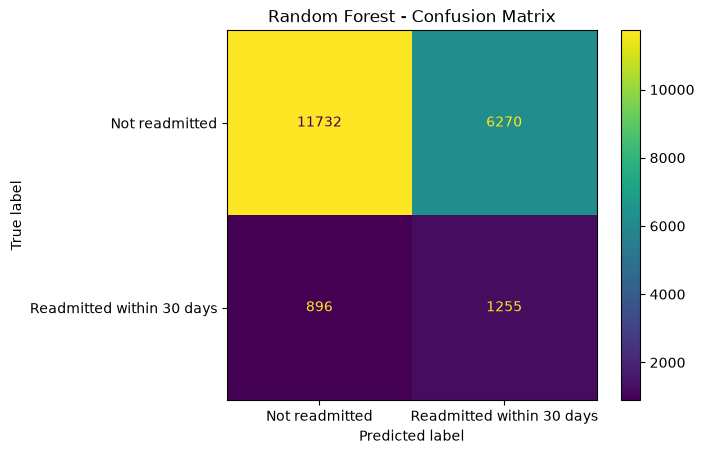

In [10]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=[
        "Not readmitted",
        "Readmitted within 30 days"
    ]
)

disp_rf.plot(values_format="d")
plt.title("Random Forest - Confusion Matrix")
plt.show()

### ROC and Precision-Recall curves

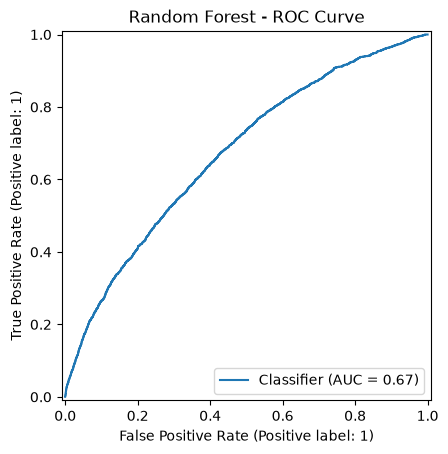

In [12]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf
)

plt.title("Random Forest - ROC Curve")
plt.show()

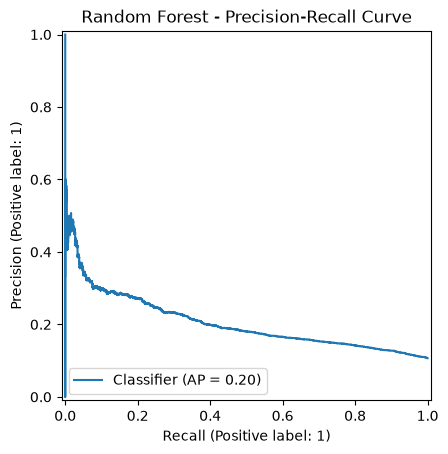

In [13]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_rf
)

plt.title("Random Forest - Precision-Recall Curve")
plt.show()

### Feature importance

In [14]:
# Get feature names from the saved feature engineering output
feature_names_path = OUTPUT_DIR / "feature_names.csv"

feature_names_df = pd.read_csv(feature_names_path)

feature_names = feature_names_df.iloc[:, 0].astype(str).tolist()

# Get feature importance values
importances = random_forest_model.feature_importances_

# Check feature name alignment
if len(feature_names) != len(importances):
    raise ValueError(
        f"Feature names ({len(feature_names)}) do not match "
        f"model features ({len(importances)}). "
        "Check the feature_names.csv generated in Feature Engineering."
    )

# Create and sort importance table
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    by="Importance",
    ascending=False
)

print("Top 20 features:")
display(importance_df.head(20))

Top 20 features:


,Feature,Importance
6,num__number_inpatient,0.155961
2379,cat__discharge_disposition_Discharged to home,0.042251
2394,cat__discharge_disposition_Expired,0.042070
5,num__number_emergency,0.038334
2385,cat__discharge_disposition_Discharged/transfer...,0.035870
3,num__num_medications,0.030936
0,num__time_in_hospital,0.026993
7,num__number_diagnoses,0.025021
1,num__num_lab_procedures,0.019806
2381,cat__discharge_disposition_Discharged/transfer...,0.019311


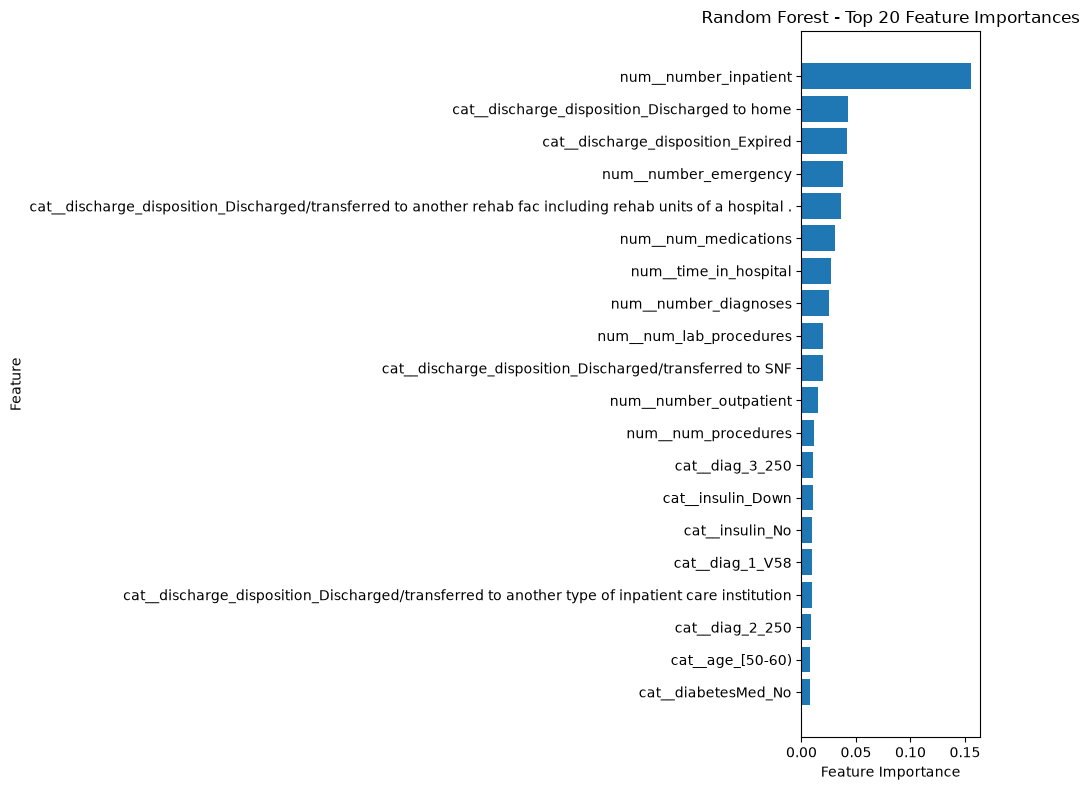

In [15]:
top_features = importance_df.head(20).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest - Top 20 Feature Importances")
plt.tight_layout()
plt.show()

### Saving the model and results

In [16]:
# Save trained model
MODEL_PATH_RF = MODEL_DIR / "random_forest_model.joblib"

joblib.dump(
    random_forest_model,
    MODEL_PATH_RF
)

# Save evaluation metrics
RESULTS_PATH_RF = OUTPUT_DIR / "random_forest_metrics.csv"

results_rf.to_csv(
    RESULTS_PATH_RF,
    index=False
)

# Save predictions
PREDICTIONS_PATH_RF = (
    OUTPUT_DIR / "random_forest_predictions.csv"
)

predictions_rf_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_rf,
    "Readmission_Probability": y_prob_rf
})

predictions_rf_df.to_csv(
    PREDICTIONS_PATH_RF,
    index=False
)

# Save feature importance
IMPORTANCE_PATH = OUTPUT_DIR / "random_forest_feature_importance.csv"

importance_df.to_csv(
    IMPORTANCE_PATH,
    index=False
)

print("Model saved to:", MODEL_PATH_RF)
print("Metrics saved to:", RESULTS_PATH_RF)
print("Predictions saved to:", PREDICTIONS_PATH_RF)
print("Feature importance saved to:", IMPORTANCE_PATH)

Model saved to: C:\Users\Lenovo\OneDrive\Documents\StadioCare-performance-analysis\models\random_forest_model.joblib
Metrics saved to: C:\Users\Lenovo\OneDrive\Documents\StadioCare-performance-analysis\outputs\random_forest_metrics.csv
Predictions saved to: C:\Users\Lenovo\OneDrive\Documents\StadioCare-performance-analysis\outputs\random_forest_predictions.csv
Feature importance saved to: C:\Users\Lenovo\OneDrive\Documents\StadioCare-performance-analysis\outputs\random_forest_feature_importance.csv
